In [24]:
from scipy.io import loadmat
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr


In [25]:
##--------- Processing Data -----------##
# load data
mat = loadmat('data/Module2_Python_Ready.mat', squeeze_me=True)

# extract raw data from MATLAB dictionary
sea_level = mat['sl']
lat  = mat['lat']
lon = mat['lon']
oni = mat['oni']

# convert MATLAB time strings into datetime
time = pd.to_datetime(mat['alt_time_str'])

# assemble the xarray dataset
# this is where we label the dimensions of our 3D array
ds = xr.Dataset(
    data_vars={
        # Format: "Variable_Name": (("Dim1", "Dim2", "Dim3"), actual_data)
        "sea_level": (("time", "lat", "lon"), sea_level),
        "oni": (("time"), oni),
    },
    coords={
        "time": time,
        "lat": lat,
        "lon": lon,
    },
    attrs={
        "description": "Sea level and ONI data for SIO175",
        "units": "meters"
    }
)

#### For each time, compute the spatially averaged sea level

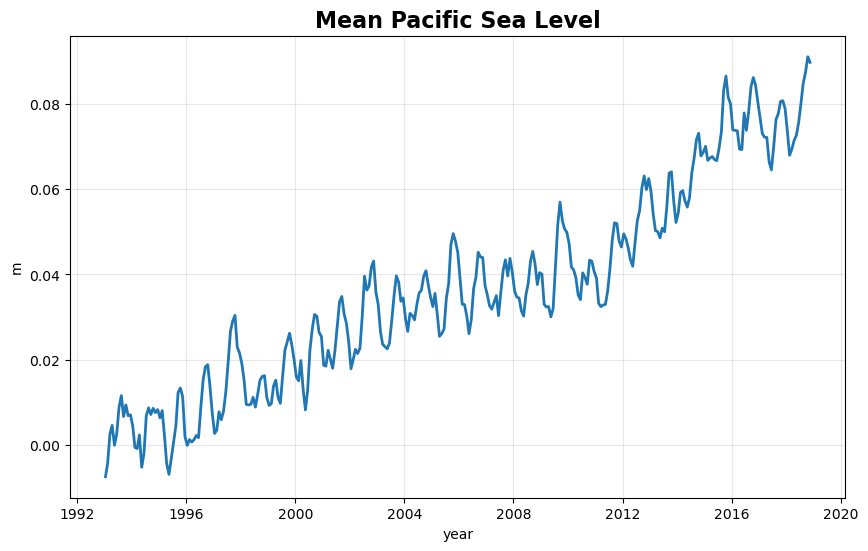

In [26]:
sl_avg = ds.sea_level.mean(dim=['lat', 'lon'])

plt.figure(figsize=(10, 6))
sl_avg.plot(linewidth=2)

plt.ylabel('m')
plt.xlabel('year')
plt.title('Mean Pacific Sea Level', fontweight='bold', fontsize=16)
plt.grid(True, alpha=0.3)
plt.show()

#### Remove the seasonal cycle

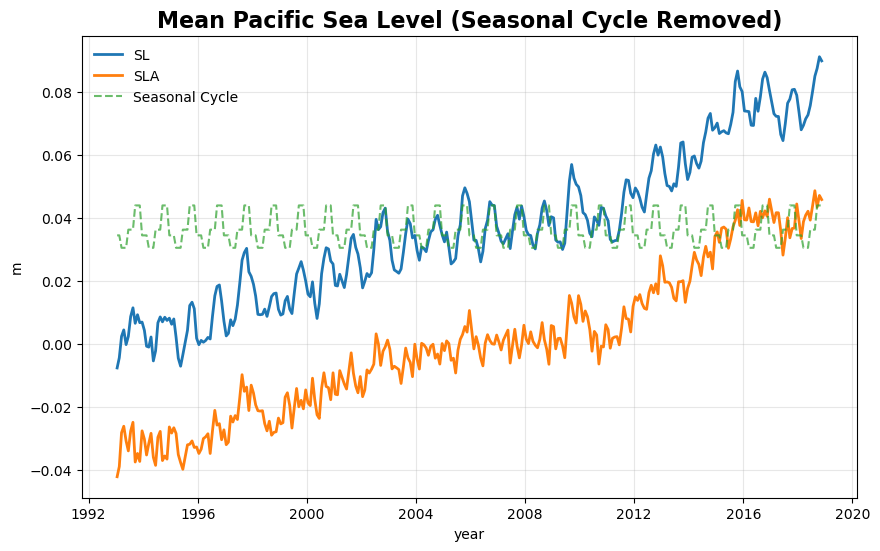

In [27]:
# compute the seasonal climatology
# This calculates the average sea level for each season across all years
clim = ds.sea_level.mean(dim=['lat', 'lon']).groupby('time.season').mean('time')

# 2. Remove the seasonal cycle to get the Sea Level Anomaly (SLA)
# We subtract the seasonal mean from the original spatially averaged time series
sla_avg = sl_avg.groupby('time.season') - clim

# 3. Plotting Figure 2 (following the style of Figure 1 in the assignment)
plt.figure(figsize=(10, 6))

# sea level (SL)
sl_avg.plot(label='SL', linewidth=2)

# sea level anomaly  (SLA)
sla_avg.plot(label='SLA', linewidth=2)

# seasonal cycle
(sl_avg - sla_avg).plot(label='Seasonal Cycle', linestyle='--', alpha=0.7)

plt.ylabel('m')
plt.xlabel('year')
plt.title('Mean Pacific Sea Level (Seasonal Cycle Removed)', fontweight='bold', fontsize=16)
plt.legend(loc='upper left', frameon=False)
plt.grid(True, alpha=0.3)
plt.show()

#### Compute and remove trend

In [28]:

# polyfit -> least squares regression
# xarray polyfit returns coefficients in [units]/nanosecond
coeff = sla_avg.polyfit(dim='time', deg=1)
slope = coeff.polyfit_coefficients.sel(degree=1)
ns_per_year = 1e9 * 3600 * 24 * 365.25
# slr in mm/yr
slr = slope * ns_per_year * 1000
print(f"Pacific sea level trend is {slr:.2f} mm/yr")

Pacific sea level trend is 2.96 mm/yr


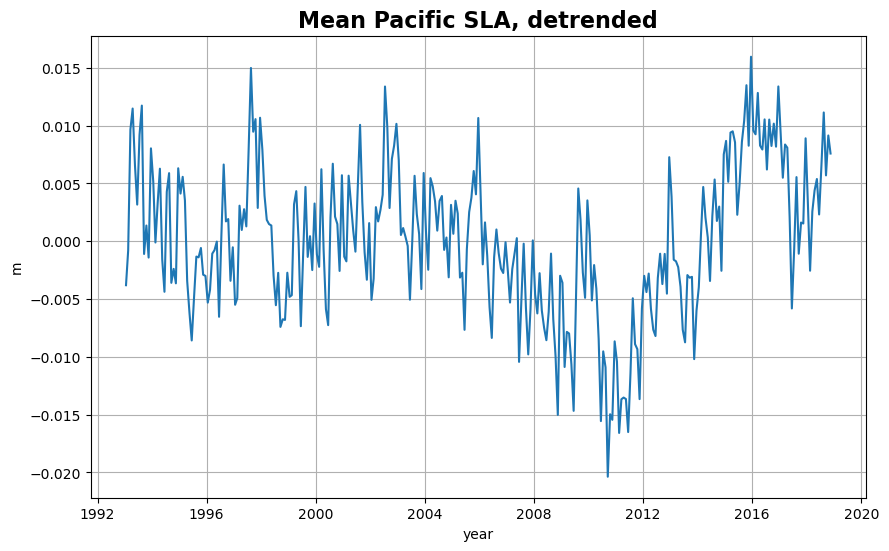

In [29]:
# remove the trend 
# # We evaluate the polynomial at the original time points and subtract it
trend_line = xr.polyval(sla_avg.time, coeff.polyfit_coefficients)
sla_det = sla_avg - trend_line

plt.figure(figsize=(10,6))
sla_det.plot(linewidth=1.5)

plt.ylabel('m')
plt.xlabel('year')
plt.title('Mean Pacific SLA, detrended', fontweight='bold', fontsize=16)
plt.grid(True)
plt.show()

#### Compare with ONI, check for serial correlation

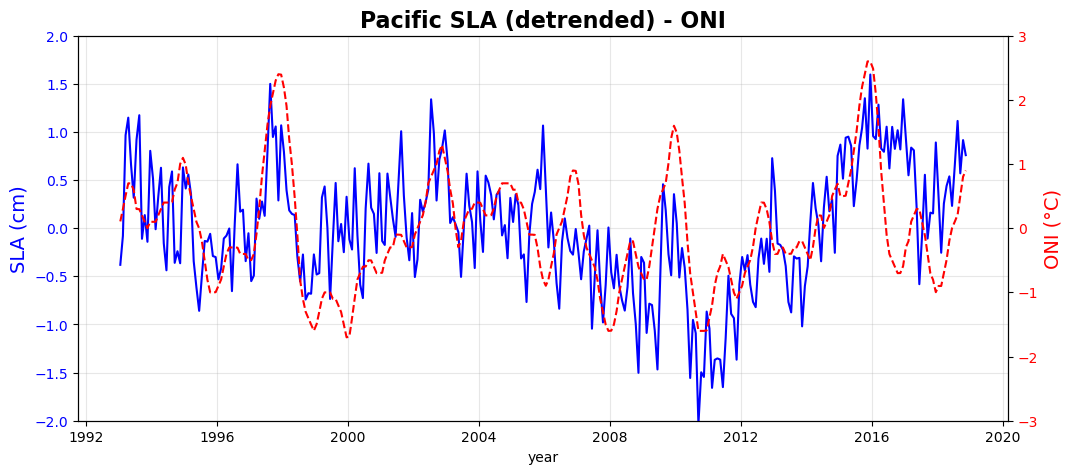

r = 0.52, p-value = 0.00


In [30]:

# Plotting with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 5))

# SLA on the left axis 
ax1.plot(sla_det.time, sla_det * 100, color='blue', linewidth=1.5, label='SLA')
ax1.set_xlabel('year')
ax1.set_ylabel('SLA (cm)', color='blue', fontsize=14)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim([-2, 2])
ax1.grid(True, alpha=0.3)

# second axis for ONI
ax2 = ax1.twinx()
ax2.plot(ds.time, ds.oni, color='red', linestyle='--', linewidth=1.5, label='ONI')
ax2.set_ylabel('ONI (°C)', color='red', fontsize=14)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim([-3, 3])

plt.title('Pacific SLA (detrended) - ONI', fontweight='bold', fontsize=16)
plt.show()

# 2. Compute correlation and p-value
# Using the same pearsonr function introduced in Assignment 2
r, p_value = pearsonr(sla_det, ds.oni)

print(f"r = {r:.2f}, p-value = {p_value:.2f}")

**Serial Correlation**
Standard p-value calculations assume that every data point is independent. However, in oceanography, the sea level today is very similar to the sea level yesterday. This means we have fewer "independent" pieces of information than the total number of months in our dataset.Because the data is "smooth" (serially correlated), the standard pearsonr function overestimates the significance, leading to that $0.00$ result. In advanced research, we would adjust the "degrees of freedom" to account for this, but for this assignment, interpreting it as "highly significant" is the standard starting point.

#### Compare with global mean sea level (GMSL.mat)


In [34]:

# load
mat = loadmat('data/GMSL.mat', squeeze_me=True)

# extract sl 
sl_values = mat['GMSL']['sl'].item()

# hardcoding not recommended, but ok for this demo
# typically a matlab script would be used here to generate time arrays
time_gmsl = pd.date_range(start='1993-01-15', periods=len(sl_values), freq='ME')

# make dataset
ds_gmsl = xr.Dataset(
    data_vars={
        "gmsl": (("time"), sl_values),
    },
    coords={
        "time": time_gmsl,
    }
)


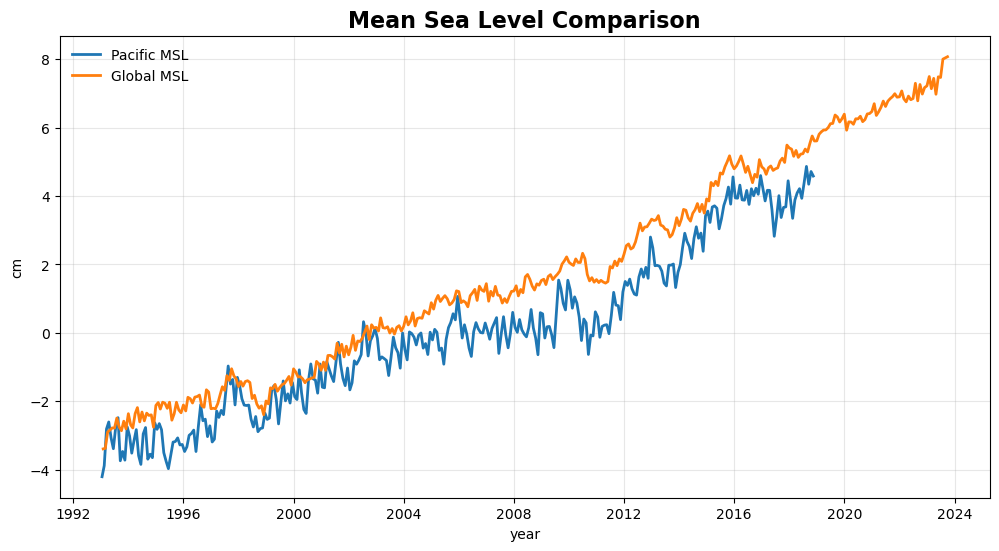

In [35]:
plt.figure(figsize=(12, 6))

# Plot sla in cm
(sla_avg * 100).plot(label='Pacific MSL', linewidth=2)

# plt gmsl in cm 
(ds_gmsl.gmsl * 100).plot(label='Global MSL', linewidth=2)

plt.ylabel('cm')
plt.xlabel('year')
plt.title('Mean Sea Level Comparison', fontweight='bold', fontsize=16)

plt.legend(loc='upper left', frameon=False)
plt.grid(True, alpha=0.3)
plt.show()

#### compare with detrended GMSL

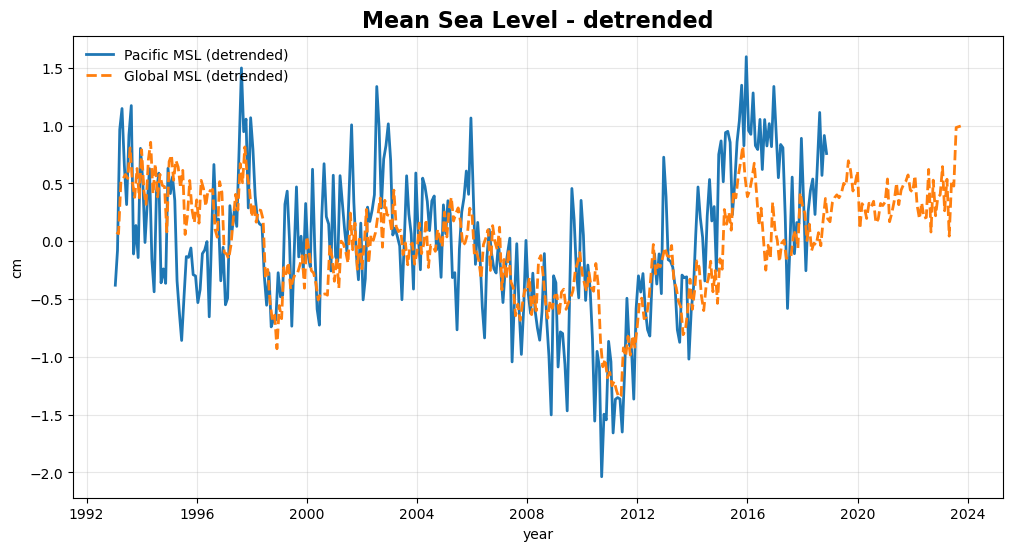

In [36]:
# fit linear tren
gmsl_trend_fit = ds_gmsl.gmsl.polyfit(dim='time', deg=1)
# evaluate trend
gmsl_trend_line = xr.polyval(ds_gmsl.time, gmsl_trend_fit.polyfit_coefficients)
# detrend signal
gmsl_det = ds_gmsl.gmsl - gmsl_trend_line

# plotting the comparison
plt.figure(figsize=(12, 6))

# plot detrended sla
(sla_det * 100).plot(label='Pacific MSL (detrended)', linewidth=2)

# Plot detrended global MSL
(gmsl_det * 100).plot(label='Global MSL (detrended)', linewidth=2, linestyle='--')

plt.ylabel('cm')
plt.xlabel('year')
plt.title('Mean Sea Level - detrended', fontweight='bold', fontsize=16)

plt.legend(loc='upper left', frameon=False)
plt.grid(True, alpha=0.3)
plt.show()

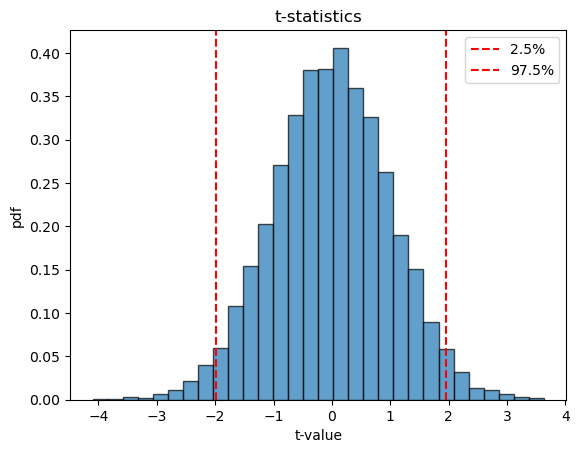

In [38]:
# data
n = 100
m = 10000
x = np.random.rand(n, m)
y = np.random.rand(n, m)

# correlation matrix
corr_matrix = np.corrcoef(x, y, rowvar=False)

# diagonal r values 
r_values = np.diag(corr_matrix[:m, m:])

# construct t from r
# t = r * sqrt((n-2) / (1-r^2))
df = n - 2
t_stats = r_values * np.sqrt(df / (1 - r_values**2))

lower_p = np.percentile(t_stats, 2.5)
upper_p = np.percentile(t_stats, 97.5)

plt.hist(t_stats, bins=30, edgecolor='black', alpha=0.7, density=True)
plt.axvline(lower_p, color='red', linestyle='--', label='2.5%')
plt.axvline(upper_p, color='red', linestyle='--', label='97.5%')
plt.title(f't-statistics')
plt.xlabel('t-value')
plt.ylabel('pdf')
plt.legend()
